# Анализ тональности комментариев

Интернет-магазин «Викишоп» запускает новый сервис. Теперь пользователи могут редактировать и дополнять описания товаров, как в вики-сообществах. То есть клиенты предлагают свои правки и комментируют изменения других. Магазину нужен инструмент, который будет искать токсичные комментарии и отправлять их на модерацию. 

<h1>Содержание<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Описание-проекта" data-toc-modified-id="Описание-проекта-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Описание проекта</a></span></li><li><span><a href="#Импорт-данных-и-разведочный-анализ" data-toc-modified-id="Импорт-данных-и-разведочный-анализ-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Импорт данных и разведочный анализ</a></span><ul class="toc-item"><li><span><a href="#Вывод" data-toc-modified-id="Вывод-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>Вывод</a></span></li></ul></li><li><span><a href="#Подготовка-и-анализ-данных" data-toc-modified-id="Подготовка-и-анализ-данных-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Подготовка и анализ данных</a></span><ul class="toc-item"><li><span><a href="#Лемматизация-и-очистка-текстов" data-toc-modified-id="Лемматизация-и-очистка-текстов-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span>Лемматизация и очистка текстов</a></span></li><li><span><a href="#Создание-тренировочной-и-тестовых-выборок,-векторизация" data-toc-modified-id="Создание-тренировочной-и-тестовых-выборок,-векторизация-3.2"><span class="toc-item-num">3.2&nbsp;&nbsp;</span>Создание тренировочной и тестовых выборок, векторизация</a></span></li><li><span><a href="#Вывод" data-toc-modified-id="Вывод-3.3"><span class="toc-item-num">3.3&nbsp;&nbsp;</span>Вывод</a></span></li></ul></li><li><span><a href="#Модель-для-предсказания-тона-комментариев" data-toc-modified-id="Модель-для-предсказания-тона-комментариев-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Модель для предсказания тона комментариев</a></span><ul class="toc-item"><li><span><a href="#Обучение-моделей" data-toc-modified-id="Обучение-моделей-4.1"><span class="toc-item-num">4.1&nbsp;&nbsp;</span>Обучение моделей</a></span><ul class="toc-item"><li><span><a href="#Logistic-Regression" data-toc-modified-id="Logistic-Regression-4.1.1"><span class="toc-item-num">4.1.1&nbsp;&nbsp;</span>Logistic Regression</a></span></li><li><span><a href="#LGBM" data-toc-modified-id="LGBM-4.1.2"><span class="toc-item-num">4.1.2&nbsp;&nbsp;</span>LGBM</a></span></li><li><span><a href="#CatBoost" data-toc-modified-id="CatBoost-4.1.3"><span class="toc-item-num">4.1.3&nbsp;&nbsp;</span>CatBoost</a></span></li><li><span><a href="#BERT" data-toc-modified-id="BERT-4.1.4"><span class="toc-item-num">4.1.4&nbsp;&nbsp;</span>BERT</a></span></li></ul></li><li><span><a href="#Сравнение-моделей" data-toc-modified-id="Сравнение-моделей-4.2"><span class="toc-item-num">4.2&nbsp;&nbsp;</span>Сравнение моделей</a></span></li><li><span><a href="#Выводы" data-toc-modified-id="Выводы-4.3"><span class="toc-item-num">4.3&nbsp;&nbsp;</span>Выводы</a></span></li><li><span><a href="#Анализ-лучшей-модели" data-toc-modified-id="Анализ-лучшей-модели-4.4"><span class="toc-item-num">4.4&nbsp;&nbsp;</span>Анализ лучшей модели</a></span><ul class="toc-item"><li><span><a href="#Метрики" data-toc-modified-id="Метрики-4.4.1"><span class="toc-item-num">4.4.1&nbsp;&nbsp;</span>Метрики</a></span></li><li><span><a href="#Важность-признаков" data-toc-modified-id="Важность-признаков-4.4.2"><span class="toc-item-num">4.4.2&nbsp;&nbsp;</span>Важность признаков</a></span></li><li><span><a href="#Сравнение-с-константной-моделью" data-toc-modified-id="Сравнение-с-константной-моделью-4.4.3"><span class="toc-item-num">4.4.3&nbsp;&nbsp;</span>Сравнение с константной моделью</a></span></li></ul></li><li><span><a href="#Вывод" data-toc-modified-id="Вывод-4.5"><span class="toc-item-num">4.5&nbsp;&nbsp;</span>Вывод</a></span></li></ul></li><li><span><a href="#Общий-вывод" data-toc-modified-id="Общий-вывод-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Общий вывод</a></span></li></ul></div>

## Описание проекта

**Заказчик**
Интернет-магазин «Викишоп»


**Входные данные**
Размеченные текстовые комментарии


**Задача**
На основе набора данных с разметкой о токсичности правок необходимо обучить модель классифицировать комментарии на позитивные и негативные. Оценка модели должна проводиться на основе метрики *F1* и ее значение должно быть не меньше 0.75


**Цель**
Создание инструмента для заказчика, который будет искать токсичные комментарии и отправлять их на модерацию

**Описание входных данных**
`toxic_comments.csv` - файл с размеченными текстовыми комментарии

- `text` - текст комментария
- `toxic` - целевой признак, токсичность комментария

In [1]:
!pip install scikit-learn --upgrade -q
!pip install hyperopt -q
!pip install lightgbm -q
!pip install wordcloud -q
!pip install --upgrade Pillow -q
!pip install spacy -q
!pip install https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-2.2.0/en_core_web_sm-2.2.0.tar.gz -q
!python -m spacy download en_core_web_sm -q
!pip install catboost -q
!pip install datasets -q
!pip install evaluate -q
!pip install accelerate -q

[+] Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [2]:
# общие
import pandas as pd
import numpy as np
import os
import re
import random
import warnings
from functools import partial
from copy import deepcopy
import time

# графики
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# мо
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    cross_val_predict,
    RandomizedSearchCV,
    StratifiedKFold
)

from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    precision_recall_curve,
    f1_score
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline

# сторонние библиотеки
import spacy
from nltk.probability import FreqDist
from wordcloud import WordCloud
from tqdm.notebook import tqdm, trange
from lightgbm import LGBMClassifier
from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
from catboost import CatBoostClassifier, Pool

import torch
from transformers import pipeline
from tokenizers import Tokenizer
import evaluate
from datasets import Dataset

tqdm.pandas()
RANDOM_STATE=42
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.use_deterministic_algorithms(True)
pd.set_option('display.max_columns', None)
warnings.filterwarnings("ignore")

## Импорт данных и разведочный анализ

In [3]:
df = pd.read_csv('toxic_comments.csv', index_col=0)
print('Сводная информация по изначальным данным \n')
df.info()
print('\n Первые записи таблицы')
display(df.head())
print('\n Соотношение классов в целевом признаке')
display(round(df['toxic'].value_counts(normalize=True)*100, 2))
print('\n Неявных пропусков в признаке text - ', df['text'].str.isspace().sum())
print('\n Дубликатов в признаке text - ', df['text'].duplicated().sum())
df.reset_index(drop=True, inplace=True)

Сводная информация по изначальным данным 

<class 'pandas.core.frame.DataFrame'>
Index: 159292 entries, 0 to 159450
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    159292 non-null  object
 1   toxic   159292 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 3.6+ MB

 Первые записи таблицы


,text,toxic
0,Explanation\nWhy the edits made under my usern...,0
1,D'aww! He matches this background colour I'm s...,0
2,"Hey man, I'm really not trying to edit war. It...",0
3,"""\nMore\nI can't make any real suggestions on ...",0
4,"You, sir, are my hero. Any chance you remember...",0



 Соотношение классов в целевом признаке


toxic
0    89.84
1    10.16
Name: proportion, dtype: float64


 Неявных пропусков в признаке text -  0

 Дубликатов в признаке text -  0


### Вывод

- Всего 159292 записи
- В таблице была колонка с индексом, возможно осталась после экспорта в `csv`, сбросили индекс
- Пропусков нет
- Неявных пропусков нет
- Дубликатов нет
- Соотношение классов в целевом признаке, есть смещение в пользу отрицательно класса
    - `0` - 89.8 %
    - `1` - 10.2 %

## Подготовка и анализ данных

### Лемматизация и очистка текстов

In [4]:
nlp = spacy.load('en_core_web_sm')
stopwords = nlp.Defaults.stop_words
stopwords.update(['t', 's', 'don', 'll', 't', 'm', 'wa', 'I'])

In [5]:
def cleaner(text): 
    # Убираем интернет-ссылки, если они есть в комментарии и спецсимволы
    text = re.sub(r'(?:(?:https?|ftp):\/\/)?[\w/\-?=%.]+\.[\w/\-&?=%.]+|\d+', '', text)
    text = re.sub(r'[^ a-zA-Z]+', '', text)
    
    return text.lower()

In [6]:
df['clean_text'] = df['text'].progress_apply(cleaner)

  0%|          | 0/159292 [00:00<?, ?it/s]

In [7]:
def lemmatize_pipe(doc):
    lemma_list = [str(tok.lemma_).lower() for tok in doc
                  if tok.is_alpha and tok.text.lower() not in stopwords] 
    return ' '.join(lemma_list)

def preprocess_pipe(texts):
    preproc_pipe = []
    for doc in tqdm(nlp.pipe(texts, n_process=-1), 
                    total=len(texts)):
        preproc_pipe.append(lemmatize_pipe(doc))
    return preproc_pipe

In [8]:
%%time
df['lemma_clean_text'] = preprocess_pipe(df['clean_text'])

  0%|          | 0/159292 [00:00<?, ?it/s]

CPU times: total: 3min 7s
Wall time: 7min 22s


In [9]:
df.head()

,text,toxic,clean_text,lemma_clean_text
0,Explanation\nWhy the edits made under my usern...,0,explanationwhy the edits made under my usernam...,explanationwhy edit username hardcore metallic...
1,D'aww! He matches this background colour I'm s...,0,daww he matches this background colour im seem...,daww match background colour seemingly stick t...
2,"Hey man, I'm really not trying to edit war. It...",0,hey man im really not trying to edit war its j...,hey man try edit war guy constantly remove rel...
3,"""\nMore\nI can't make any real suggestions on ...",0,morei cant make any real suggestions on improv...,morei not real suggestion improvement wonder s...
4,"You, sir, are my hero. Any chance you remember...",0,you sir are my hero any chance you remember wh...,sir hero chance remember page


In [10]:
#df.to_csv('toxic_comments_lem.csv', index=False)

In [11]:
def get_wordcloud(texts, title):
    
    text = ' '.join(texts.values)
    plt.figure(figsize=(18, 9))
    plt.imshow(
        WordCloud(width = 2000, 
                  height = 1000, 
                  collocations=False,
                  background_color='white',
                  random_state=RANDOM_STATE).generate(text))
    plt.axis('off')
    plt.title(title, fontsize=20)
    plt.show()
    
    fdist = FreqDist(texts.str.split().explode().to_list())
    fdist = pd.Series(dict(fdist)).sort_values(ascending=False)
    fdist = round(fdist.head(20) * 100 / fdist.sum(), 2)
    plt.figure(figsize=(18, 6))
    sns.set(style='whitegrid', font_scale = 1.3, rc={'axes.edgecolor': 'black'})
    sns.barplot(x=fdist.index, y=fdist.values)
    plt.title(title, fontsize=16)
    plt.ylabel('Процент от всех слов в подгруппе', fontsize=14)
    plt.xticks(rotation=45)

Отлично, посмотрим на самые частые слова

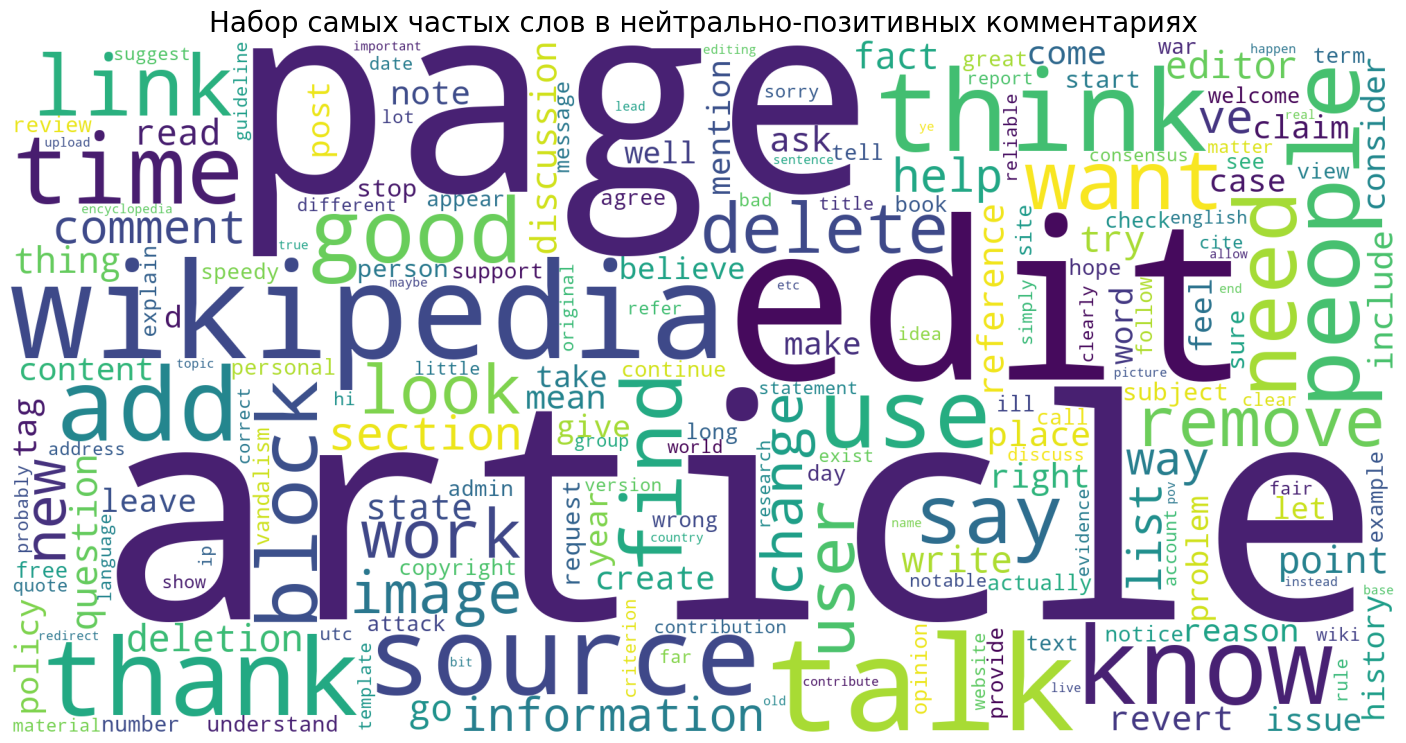

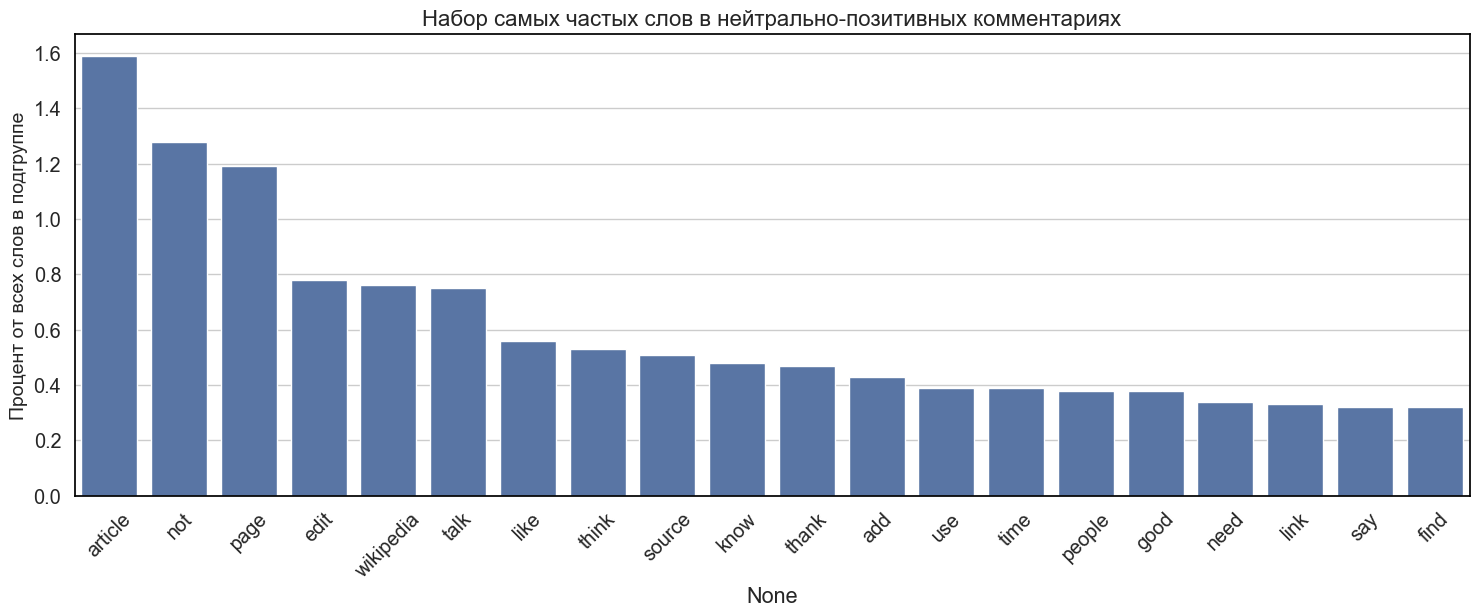

In [12]:
get_wordcloud(df.query('toxic==0')['lemma_clean_text'], 
              'Набор самых частых слов в нейтрально-позитивных комментариях')

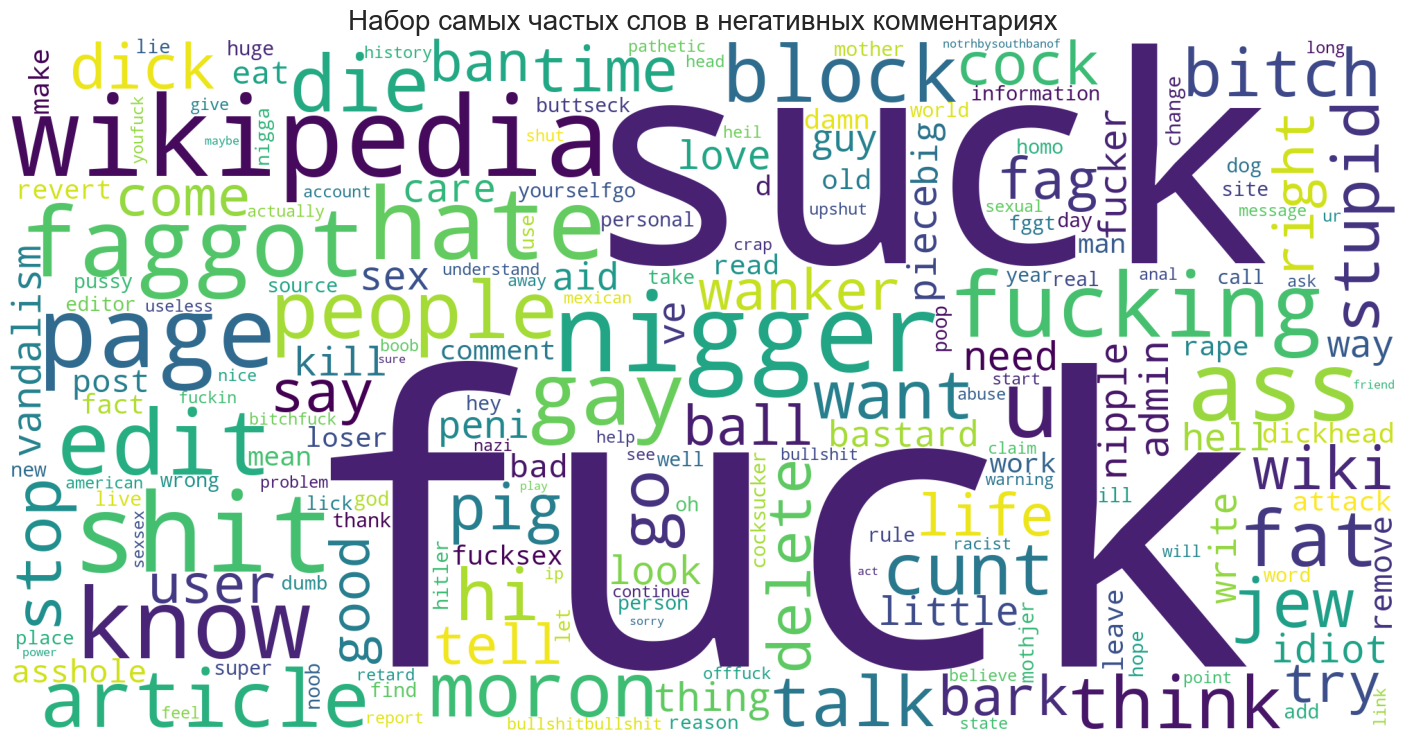

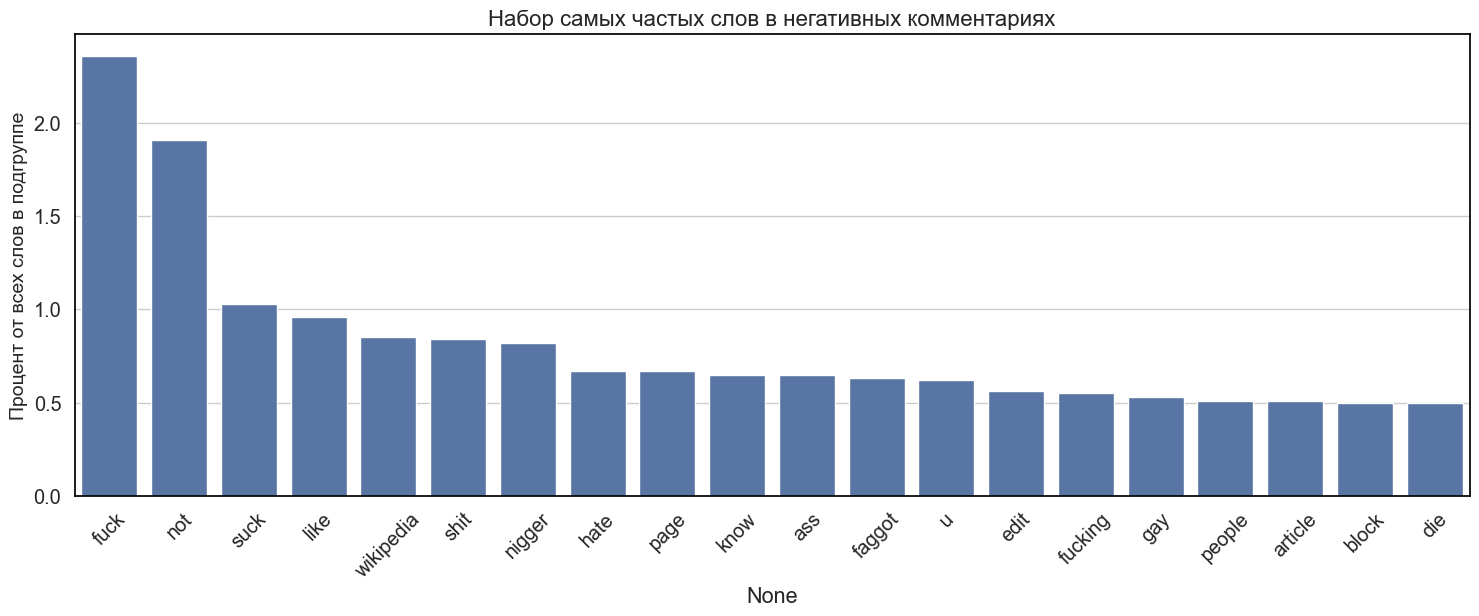

In [13]:
get_wordcloud(df.query('toxic==1')['lemma_clean_text'], 
              'Набор самых частых слов в негативных комментариях')

Видны явные различия между позитивно-нейтральными комментариями и негативными, заодно добавили в словарь стоп-слов остатки вроде `ll`, `w` и т.д.

### Создание тренировочной и тестовых выборок, векторизация

Разделим данные

In [14]:
X_train, X_test, y_train, y_test = train_test_split(df[['lemma_clean_text', 'clean_text']], 
                                                    df['toxic'],
                                                    test_size=0.2,
                                                    shuffle=True, 
                                                    stratify=df['toxic'], 
                                                    random_state=RANDOM_STATE)

# Создадим отдельно набор для берта только из очищенного текста
X_valid_bert = X_train['clean_text']
valid_bert = pd.concat([X_valid_bert, y_train], axis=1)
valid_bert = valid_bert.sample(frac=0.03, random_state=RANDOM_STATE)
X_valid_bert = valid_bert['clean_text']
y_valid_bert = valid_bert['toxic']

X_train = X_train['lemma_clean_text']
X_test = X_test['lemma_clean_text']

In [15]:
display(X_valid_bert.shape)
display(round(valid_bert['toxic'].value_counts(normalize=True)*100, 2))

(3823,)

toxic
0    89.46
1    10.54
Name: proportion, dtype: float64

Для BERT возьмем отдельно валидационную выборку

In [16]:
train_pool = Pool(data=X_train.to_list(), label=y_train, text_features=[0])
test_pool = Pool(data=X_test.to_list(), label=y_test, text_features=[0])

Создадим наборы для CatBoost

### Вывод

- Токенизировали и убрали спецсимволы
- Лемматизировали
- Убрали стоп-слова из словаря `Spacy`, в который добавили остатки вроде `ll`, `nt` и т.д.
- Отдельно оставили обработанные, но не векторизованные данные для `CatBoost`, где будем использовать `text_processing`
- По самым частым словам в группе позитивно-нейтральных и негативных комментариев наблюдается заметная разница

## Модель для предсказания тона комментариев

Будем обучать три модели и подбирать гиперпараметры с помощью HyperOpt с кросс-валидацией:
- LogisticRegression
- LGBM
- CatBoost с использованием встроенных преобразований текста и подбором гиперпараметров с кросс-валидацией


Оценивать модели будем по метрике `F1`

### Обучение моделей

Зададим целевую функцию для HyperOpt и вспомогательную для поиска лучшей модели

In [17]:
def objective(params, model_type, X, y):
    
    model = model_type.set_params(**params)
    skf = StratifiedKFold(n_splits=3, random_state=RANDOM_STATE, shuffle=True)
    score = cross_val_score(estimator=model, X=X, y=y, 
                            scoring='f1', cv=skf, n_jobs=-1)

    return {'loss': -score.mean(),
            'status': STATUS_OK,
            'model': deepcopy(model)
           }

In [18]:
def getBestModelfromTrials(trials):
    valid_trial_list = [trial for trial in trials
                            if STATUS_OK == trial['result']['status']]
    losses = [ float(trial['result']['loss']) for trial in valid_trial_list]
    index_having_minumum_loss = np.argmin(losses)
    best_trial_obj = valid_trial_list[index_having_minumum_loss]
    return best_trial_obj['result']['model'], -round(best_trial_obj['result']['loss'], 3)

Зададим функцию для моделирования и сбора результатов для сравнения моделей

In [19]:
def model_search(model_type, param_search, name, X_train, y_train, eval_num=10):
    
    if name=='CatBoost':
        model = deepcopy(model_type)
        results = model.randomized_search(
                                        param_search,
                                        X=X_train,
                                        partition_random_seed=RANDOM_STATE,
                                        stratified=True,
                                        verbose=False,
                                        cv=3,
                                        n_iter=eval_num,
                                        search_by_train_test_split=False)
    
    else: 
        trials = Trials()
        results = fmin(
                        partial(objective, model_type=model_type, X=X_train, y=y_train),
                        space=param_search,
                        algo=tpe.suggest,
                        trials=trials,
                        max_evals=eval_num
                      )

    if name=='CatBoost':
        best_model = deepcopy(model)
        best_loss = np.max(results['cv_results']['test-F1-mean'])
    else:
        best_model, best_loss = getBestModelfromTrials(trials)
        
    start = time.time()
    best_model.fit(X_train, y_train)
    end = time.time()
    fit_time = round(end-start, 2)
    
    print(f'F1 лучшей модели: {best_loss}')
    display(best_model)
    
    results = {'model': name,
               'cv_F1': best_loss,
               'fit_time': fit_time
              }
    
    return best_model, results

In [20]:
# tf_idf + model
pipe = Pipeline(
        [
            ('tf_idf', TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True)),
            ('model', LogisticRegression(random_state=RANDOM_STATE))
        ])

#### Logistic Regression

In [21]:
%%time
logreg_param = {'model': LogisticRegression(random_state=RANDOM_STATE, 
                                            n_jobs=-1, 
                                            max_iter=7000),
                'model__C': hp.choice('C', [1, 10, 100]),
                'model__solver': hp.choice('solver', ['lbfgs']),
                'model__fit_intercept' : hp.choice('fit_intercept', [True, False])
               }
model_logreg, res_logreg = model_search(pipe,
                                        logreg_param,
                                        'LogReg',
                                        X_train,
                                        y_train,
                                        eval_num=10)

100%|███████████████████████████████████████████████| 10/10 [05:04<00:00, 30.42s/trial, best loss: -0.7772935520919217]
F1 лучшей модели: 0.777


Pipeline(steps=[('tf_idf',
                 TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True)),
                ('model',
                 LogisticRegression(C=100, max_iter=7000, n_jobs=-1,
                                    random_state=42))])

CPU times: total: 17.1 s
Wall time: 5min 39s


#### LGBM

In [22]:
%%time
lgbm_param = {'model': LGBMClassifier(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
              'model__reg_lambda' : hp.choice('reg_lambda', [0.1, 1, 5]),
              'model__max_depth': hp.choice('max_depth', np.arange(0, 1, dtype=int)),
              'model__n_estimators' : hp.choice('n_estimators', np.arange(500, 1001, 200, dtype=int)),
              'model__learning_rate': hp.choice('learning_rate', [0.01, 0.1, 1.]),
              'model__colsample_bytree': hp.choice('colsample_bytree', [0.5, 0.75, 1.])
             }
model_lgbm, res_lgbm = model_search(pipe,
                                    lgbm_param,
                                    'LGBM',
                                    X_train,
                                    y_train,
                                    eval_num=5)

100%|█████████████████████████████████████████████████| 5/5 [18:39<00:00, 223.93s/trial, best loss: -0.767008966051328]
F1 лучшей модели: 0.767


Pipeline(steps=[('tf_idf',
                 TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True)),
                ('model',
                 LGBMClassifier(colsample_bytree=0.5, max_depth=0,
                                n_estimators=500, n_jobs=-1, random_state=42,
                                reg_lambda=0.1, verbose=-1))])

CPU times: total: 12min 13s
Wall time: 21min 10s


#### CatBoost

Создадим словарь для обработки текста с помощью `text_processing`

In [23]:
text_params = {
        'tokenizers' : [
                        {
                        'tokenizer_id' : 'Space',
                        'separator_type' : 'ByDelimiter',
                        'delimiter' : ' ',
                        'lowercasing': 'True'    
                        }
                       ],
        
        'dictionaries' : [
                          {
                           'dictionary_id' : 'BiGram',
                           'token_level_type': 'Word',
                           'gram_order' : '2'
                          }, 
                          {
                           'dictionary_id' : 'Word',
                           'token_level_type': 'Word',
                           'gram_order' : '1'
                          }
                        ],
    
        'feature_processing' : {
            'default' : [
                        {
                        'dictionaries_names' : ['BiGram', 'Word'],
                        'feature_calcers' : ['BoW'],
                        'tokenizers_names' : ['Space']
                        }, 
                        {
                        'dictionaries_names' : ['BiGram', 'Word'],
                        'feature_calcers' : ['NaiveBayes'],
                        'tokenizers_names' : ['Space']
                        },
                        {
                        'dictionaries_names' : ['Word'],
                        'feature_calcers' : ['BM25'],
                        'tokenizers_names' : ['Space']
                        }
                        ]
                    }
                }

Подбор гиперпараметров будем проводить с помощью встроенного `randomzed_search`

In [24]:
%%time
catboost_param = {'learning_rate': [0.1, 0.3, 1.],
                  'depth': np.arange(2, 6, dtype=int),
                  'l2_leaf_reg': [0.1, 1., 10, 100]}

model_catboost, res_catboost = model_search(CatBoostClassifier(random_seed=RANDOM_STATE, 
                                                              thread_count=-1, 
                                                              verbose=False,
                                                              od_type='Iter',
                                                              od_wait=500, 
                                                              eval_metric='F1',
                                                              text_processing=text_params),
                                            catboost_param,
                                            'CatBoost',
                                            train_pool,
                                            None,
                                            eval_num=5)

Training on fold [0/3]

bestTest = 0.7629678267
bestIteration = 694

Training on fold [1/3]

bestTest = 0.7609147609
bestIteration = 998

Training on fold [2/3]

bestTest = 0.7669502449
bestIteration = 537

Training on fold [0/3]

bestTest = 0.7668025779
bestIteration = 444

Training on fold [1/3]

bestTest = 0.7646526071
bestIteration = 545

Training on fold [2/3]

bestTest = 0.772198799
bestIteration = 651

Training on fold [0/3]

bestTest = 0.7674050633
bestIteration = 970

Training on fold [1/3]

bestTest = 0.7631613325
bestIteration = 759

Training on fold [2/3]

bestTest = 0.769012266
bestIteration = 996

Training on fold [0/3]

bestTest = 0.7675180092
bestIteration = 775

Training on fold [1/3]

bestTest = 0.7654160717
bestIteration = 441

Training on fold [2/3]

bestTest = 0.7722007722
bestIteration = 249

Training on fold [0/3]

bestTest = 0.7655565875
bestIteration = 772

Training on fold [1/3]

bestTest = 0.7645675464
bestIteration = 940

Training on fold [2/3]

bestTest = 0

CPU times: total: 1h 55min 49s
Wall time: 24min 59s


Отлично, обучили три модели, и теперь попробуем посмотреть на предобученный BERT

#### BERT

Посмотрим на показатели готовой модели BERT на токсичные комментарии (https://huggingface.co/unitary/toxic-bert) со 109 млн. параметров

In [25]:
# переводим вероятности в классы
def to_labels(predict_proba, thrsld):
    return (predict_proba >= thrsld).astype('int')

In [26]:
bert_model = pipeline('sentiment-analysis', 
                      model='unitary/toxic-bert', 
                      use_fast=True,
                      device='cpu')

Device set to use cpu


In [27]:
start = time.time()
preds = bert_model(X_valid_bert.to_list(), padding=True, 
                   max_length=512,
                   truncation=True,
                   batch_size=6)
end = time.time()
bert_predict_time = round(end-start, 2)

In [28]:
y_pred_bert = to_labels(pd.DataFrame(preds)['score'], 0.5)

In [29]:
bert_score = f1_score(y_pred_bert, y_valid_bert)
print('F1-метрика на 4000 объектах - ', bert_score)
print(f'Время предсказания - {bert_predict_time} с')

F1-метрика на 4000 объектах -  0.9263420724094882
Время предсказания - 692.26 с


In [30]:
res_bert = {'model': 'Pretrained BERT*',
           'cv_F1': bert_score,
           'fit_time': bert_predict_time
          }

### Сравнение моделей

In [31]:
comparison = pd.DataFrame({key: [res_logreg[key],  
                                 res_lgbm[key],
                                 res_catboost[key],
                                 res_bert[key]] for key in res_logreg})
comparison = comparison.sort_values(by='cv_F1', ascending=False)

,model,cv_F1,fit_time
3,Pretrained BERT*,0.926342,692.26
0,LogReg,0.777000,35.66
1,LGBM,0.767000,151.05
2,CatBoost,0.766761,110.15


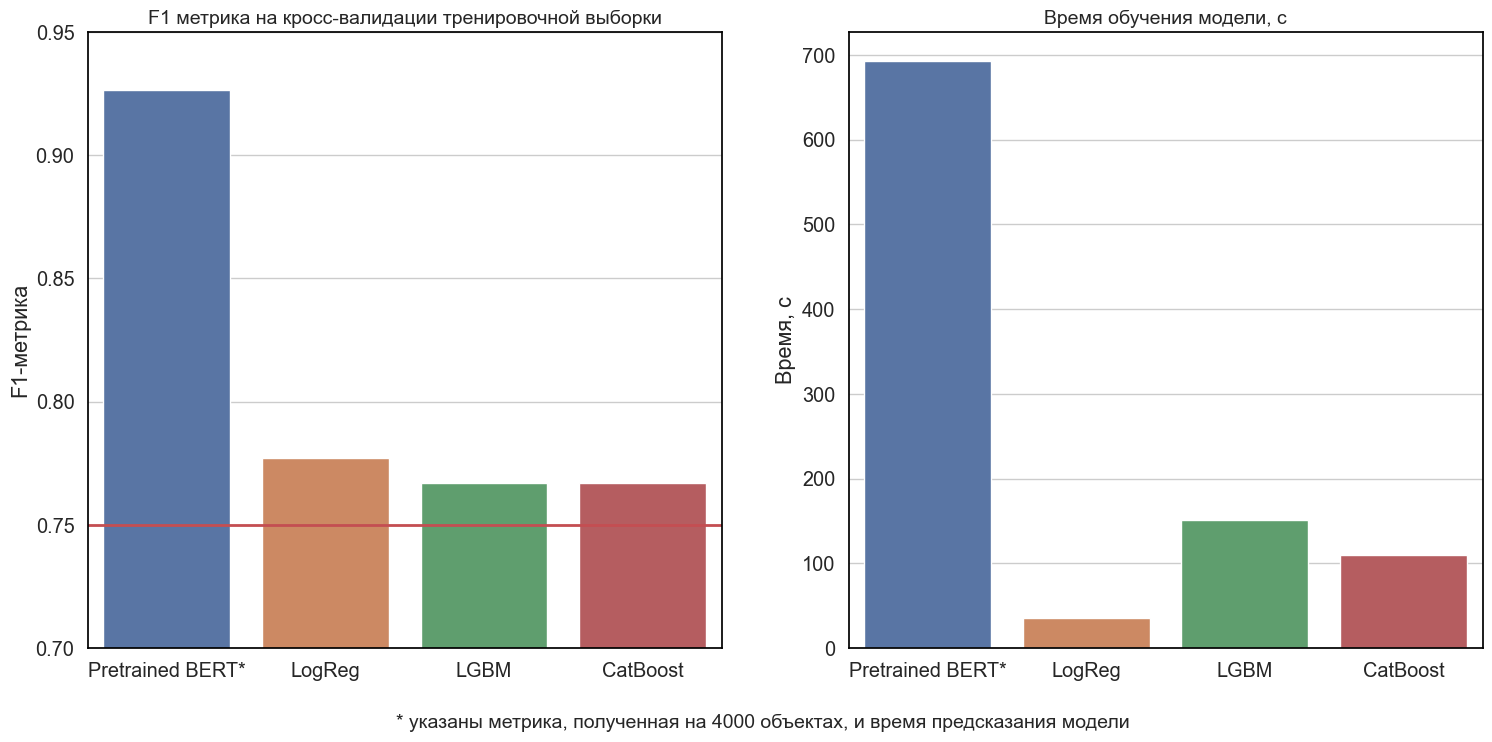

In [32]:
titles = [
          'F1 метрика на кросс-валидации тренировочной выборки', 
          'Время обучения модели, с',
         ]
ylabel = [
          'F1-метрика',
          'Время, с'
         ]
text = '* указаны метрика, полученная на 4000 объектах, и время предсказания модели'
fig, ax = plt.subplots(1, 2, figsize=(18,8))
for idx, col in enumerate(comparison.iloc[:,1:]):
    bar = sns.barplot(data=comparison, 
                      x='model', 
                      y=col,
                      hue='model',
                      ax=ax[idx])
    bar.set_title(f'{titles[idx]}', fontsize=14)
    bar.set_xlabel('')
    bar.set_ylabel(f'{ylabel[idx]}')
ax[0].axhline(color='r', y=0.75, linestyle='-', linewidth=2)
ax[0].set_ylim(bottom=0.7, top=0.95)
plt.figtext(0.5, 0.01, 
            text, 
            ha='center', 
            fontsize=14)
comparison

In [33]:
best_model = model_logreg

In [34]:
best_model

Pipeline(steps=[('tf_idf',
                 TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True)),
                ('model',
                 LogisticRegression(C=100, max_iter=7000, n_jobs=-1,
                                    random_state=42))])

### Выводы

- Обучили три модели с подбором гиперпараметров и протестировали предобученную модель BERT
    - BERT - 0.926
    - LogisticRegression - 0.777
    - CatBoost - 0.769
    - LGBM - 0.768
- Быстрее всего обучается логистическая регрессия, медленнее всего - BERT
- Встает сложный выбор, BERT или LogisticRegression, который упирается в мощности заказчика
- Выберем логистическую регрессию, так как данная модель выполняет требования заказчика по метрике и значительно превосходит по скорости остальные модели
    - LogisticRegression с F1-метрикой - **0.777**
    - Гиперпараметры
        - `С` - 100
        - `max_iter` - 7000
        - `fit_intercept` - True
        - `solver` - `lbfgs`
    - Самая быстрая модель
- При наличии у заказчика достаточных мощностей имеет смысл рассмотреть BERT

### Анализ лучшей модели

#### Метрики

Посмотрим на другие метрики модели, и выясним необходимость настройки порога

In [35]:
# Создадим функцию для вывода метрики модели
# Принимает на вход y_test - тестовая выборка, predictions - предсказание целевого признака
def model_metrics(y_test, predictions, name):
    print(f'Recall - {round(recall_score(y_test, predictions), 3)}')
    print(f'Precision - {round(precision_score(y_test, predictions), 3)}')
    print(f'Accurcay - {round(accuracy_score(y_test, predictions), 3)}')
    print(f'F1 score - {round(f1_score(y_test, predictions), 3)}')
    cm = confusion_matrix(y_test, predictions)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues_r')
    plt.title(f'Матрица ошибок {name}')
    plt.xlabel('Предсказанный класс')
    plt.ylabel('Истинный класс')

In [36]:
pred_train_cv = cross_val_predict(best_model, 
                                  X_train, 
                                  y_train, 
                                  cv=3, 
                                  method='predict')
pred_proba_train_cv = cross_val_predict(best_model, 
                                        X_train, 
                                        y_train, 
                                        cv=3, 
                                        method='predict_proba')[:,1]

Recall - 0.716
Precision - 0.838
Accurcay - 0.957
F1 score - 0.772


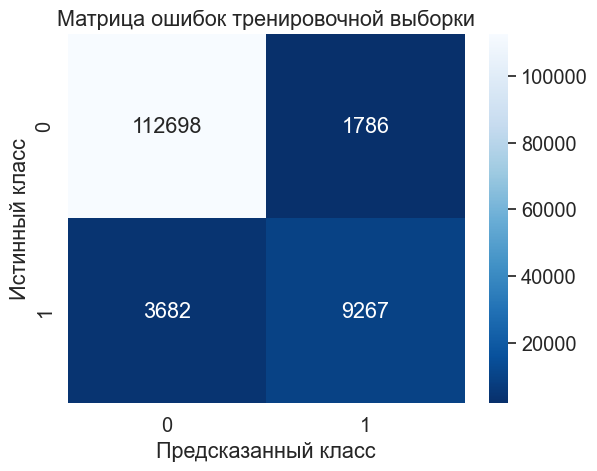

In [37]:
model_metrics(y_train,
              pred_train_cv,
              'тренировочной выборки')

Опишем матрицу ошибок

- Модель достаточно хорошо определяет позитивно-нейтральные и негативные комментарии
- Ошибки первого рода, т.е. определение позитивного комментария как негативного составляют около 1.5 % (1786)
- Ошибки второго рода, т.е. определение негативного комментария как позитивного составляют около 28.4 % (3682)
- Полнота модели, т.е. охват всех негативных комментариев 71.6 %, а точность - т.е. верные предсказания негативных комментариев из всех предсказаний - 83.8 %
- Нас интересует больше охват, так как лучше пометить обычный комментарий как негативный и дальше включить модерацию, чем пропустить негативный, кроме того, у нас есть запас по точности
- Попробуем слегка сместить порог для уменьшения ошибок второго рода и увеличения охвата за счет точности

Посмотрим на кривую Precision-Recall

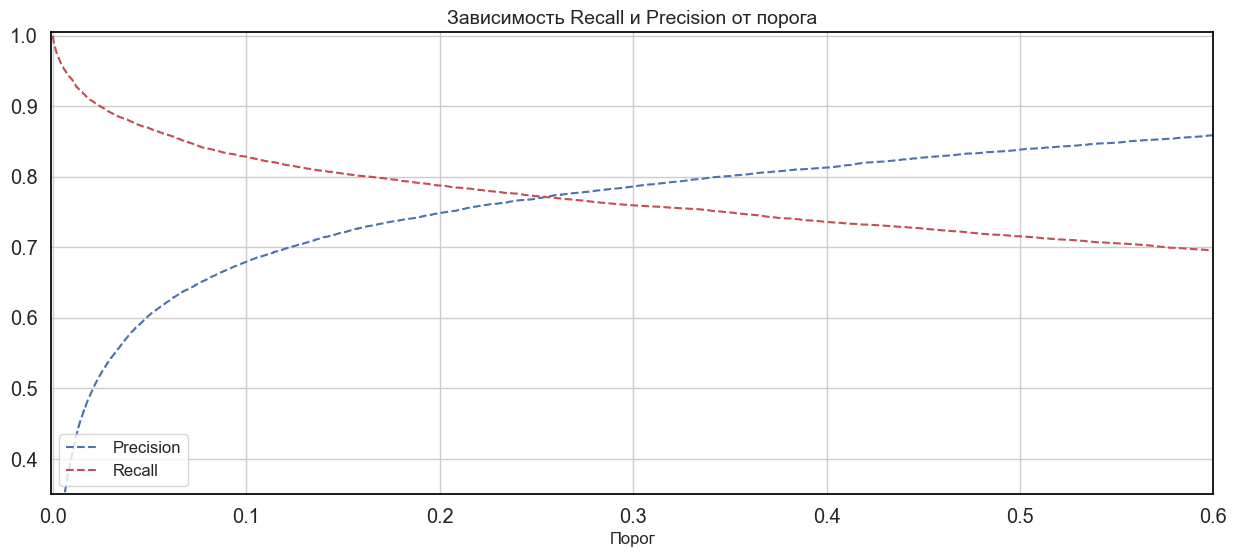

In [38]:
# Найдем все значения precision, recall и порога для тестовой выборки и предсказаний
precision, recall, threshold  = precision_recall_curve(y_train, 
                                                       pred_proba_train_cv)

# Построим графики зависимостей
plt.figure(figsize=(15,6))
plt.title('Зависимость Recall и Precision от порога', fontsize=14)
plt.plot(threshold, precision[:-1], 'b--', label='Precision')
plt.plot(threshold, recall[:-1], 'r--', label='Recall')
plt.xlabel('Порог', fontsize=12)
plt.legend(loc='lower left', fontsize=12)
plt.ylim([0.35, 1.005])
plt.xlim([min(threshold)-0.001, 0.6])
plt.grid(True);

Попробуем увеличить Recall за счет Precision, так как у нас есть дисбалланс классов и заказчику важнее для бизнеса определять как можно больше токсичных комментариев

Recall - 0.749
Precision - 0.801
Accurcay - 0.956
F1 score - 0.774


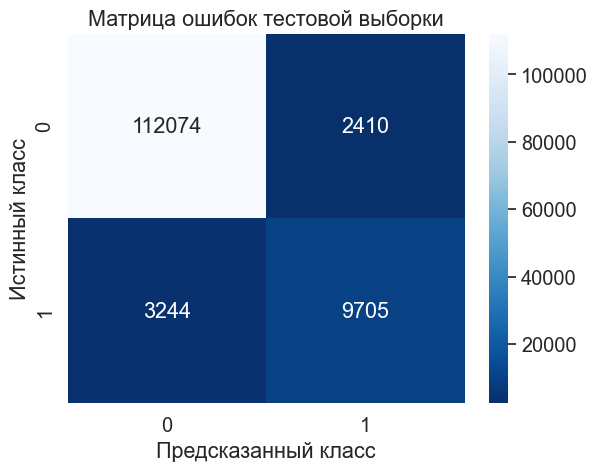

In [39]:
pred_train_cv_with_threshold = (pred_proba_train_cv > 0.35).astype(int)
model_metrics(y_train,
              pred_train_cv_with_threshold,
              'тестовой выборки')

Неплохо, точность все еще высокая, при этом заметно увеличили охват. Посмотрим на метрики модели на тестовой выборке

Recall - 0.774
Precision - 0.794
Accurcay - 0.957
F1 score - 0.784


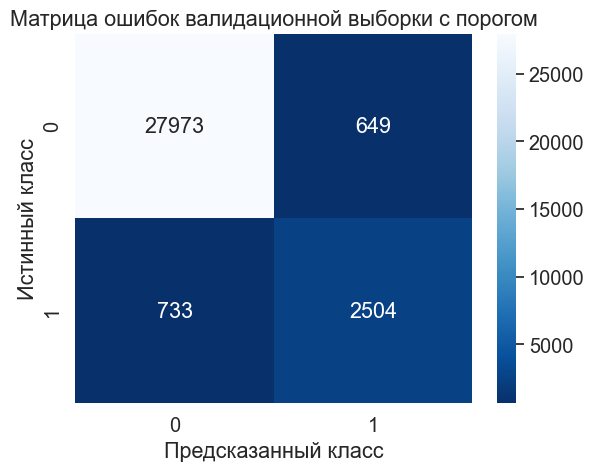

In [40]:
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:,1]
# Немного варьируем порог и рассчитываем метрику модели с порогом
pred_with_threshold = (y_pred_proba > 0.35).astype(int)
model_metrics(y_test, 
              pred_with_threshold, 
              'валидационной выборки с порогом')

Отлично, F1-метрика 0.784 больше 0.75, что подходит под условие заказчика, при этом Recall - 0.774 и Precision - 0.794

- Модель хорошо определяет негативные комментарии из всех негативных - 77.4 %, а так же обычные комментарии - 97.7 %
- Ошибки первого рода, т.е. определение позитивного комментария как негативного составляют около 2.3 % (649)
- Ошибки второго рода, т.е. определение негативного комментария как позитивного составляют около 22.6 % (733)
- Полнота модели, т.е. охват всех негативных комментариев 77.4 %, точность - т.е. верные предсказания негативных комментариев из всех предсказаний - те же 79.4 %

#### Важность признаков

In [41]:
features = best_model['tf_idf'].get_feature_names_out().tolist()
coefs = best_model['model'].coef_.tolist()[0]
sorted_features = sorted(zip(coefs, features), reverse=True)
top = [x[::-1] for x in sorted_features[:200]]
bot = [(x[1], abs(x[0])) for x in sorted_features[-200:]][::-1]

In [42]:
def features_importance(data, title):
    wordcloud = WordCloud(width = 2000, 
                          height = 1000, 
                          collocations=False,
                          background_color='white',
                          random_state=RANDOM_STATE).generate_from_frequencies(dict(data))
    plt.figure(figsize=(18, 9))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(title, fontsize=20)
    plt.show()
    
    df_ = pd.DataFrame(data, columns=['word', 'importance'])[:20]
    plt.figure(figsize=(18, 6))
    sns.barplot(x=df_.word, y=df_.importance)
    plt.title(title, fontsize=16)
    plt.ylabel('Абсолютная важность слова', fontsize=14)
    plt.xticks(rotation=45)

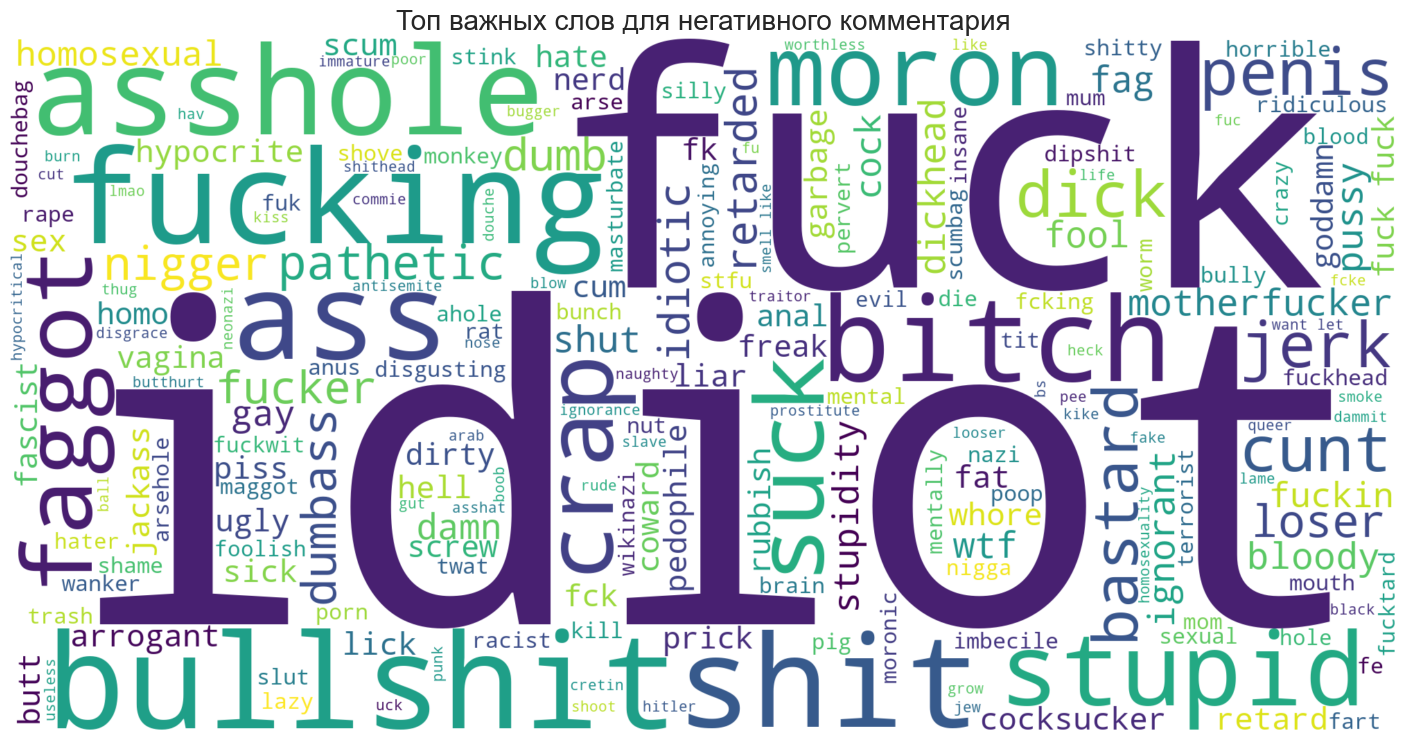

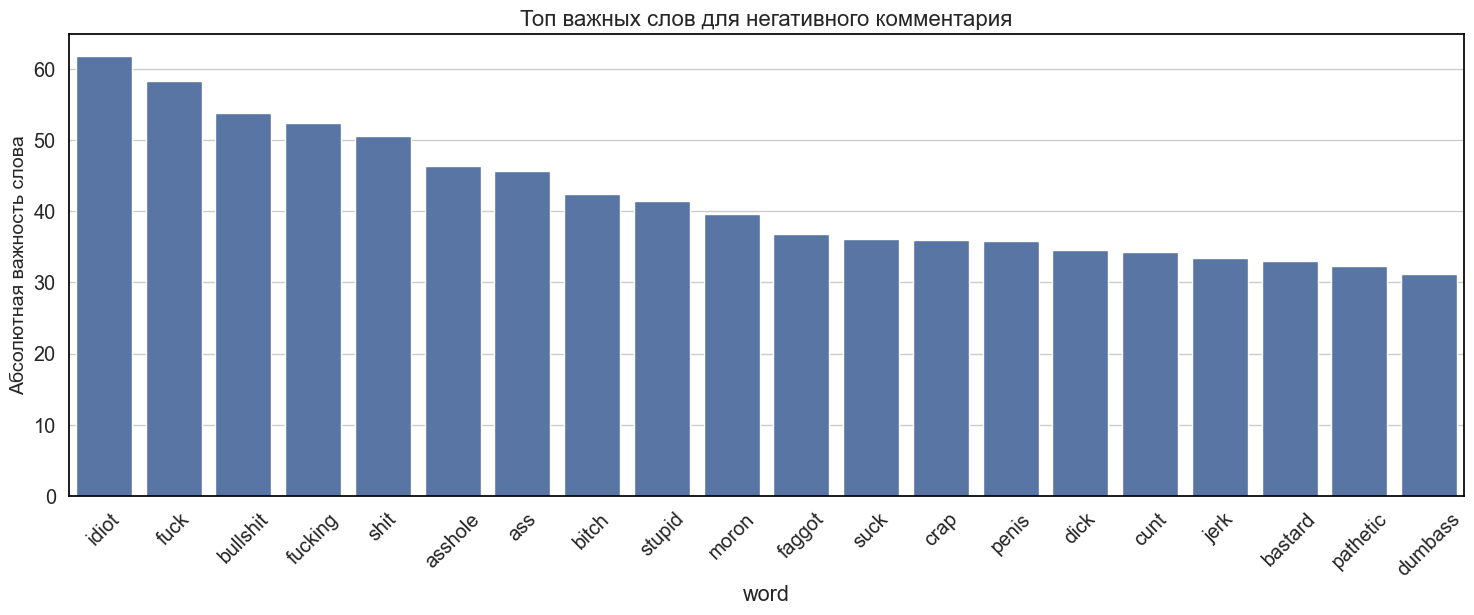

In [43]:
features_importance(top, 'Топ важных слов для негативного комментария')

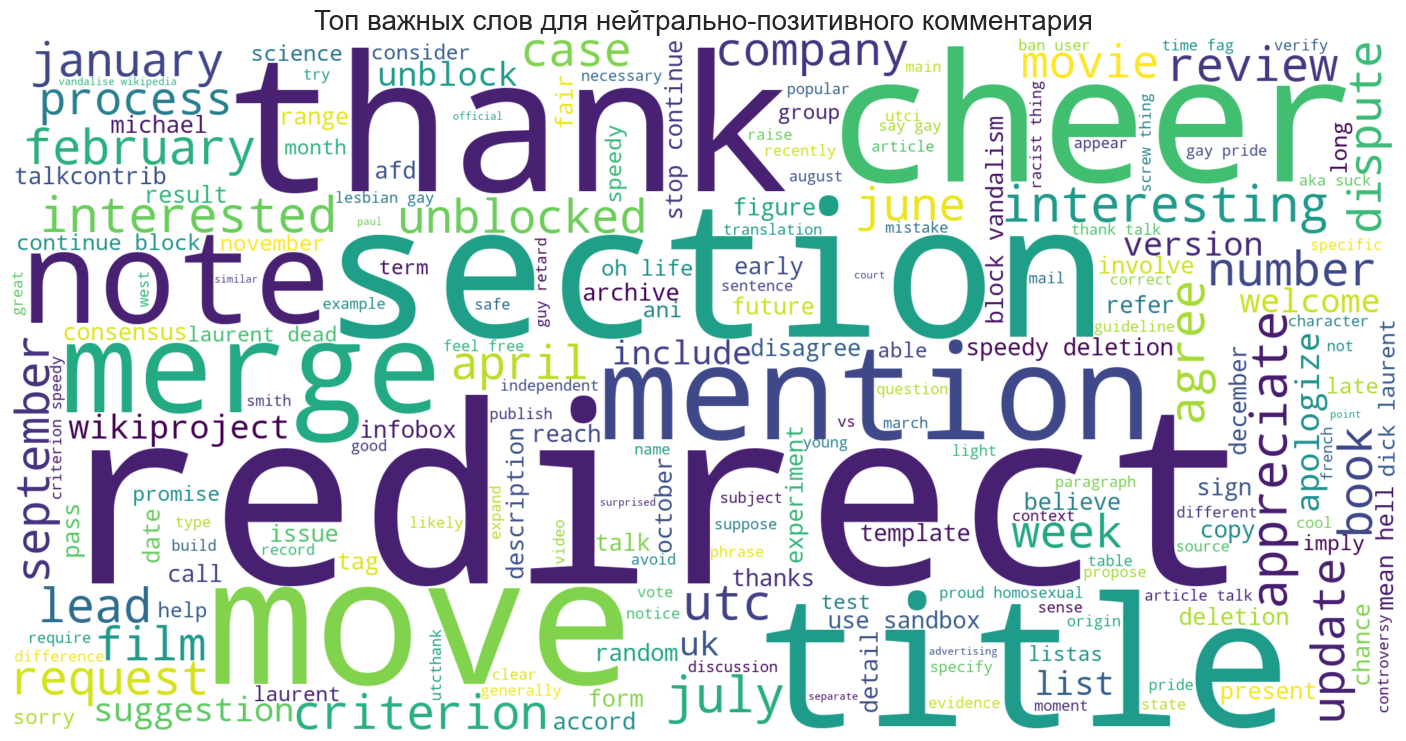

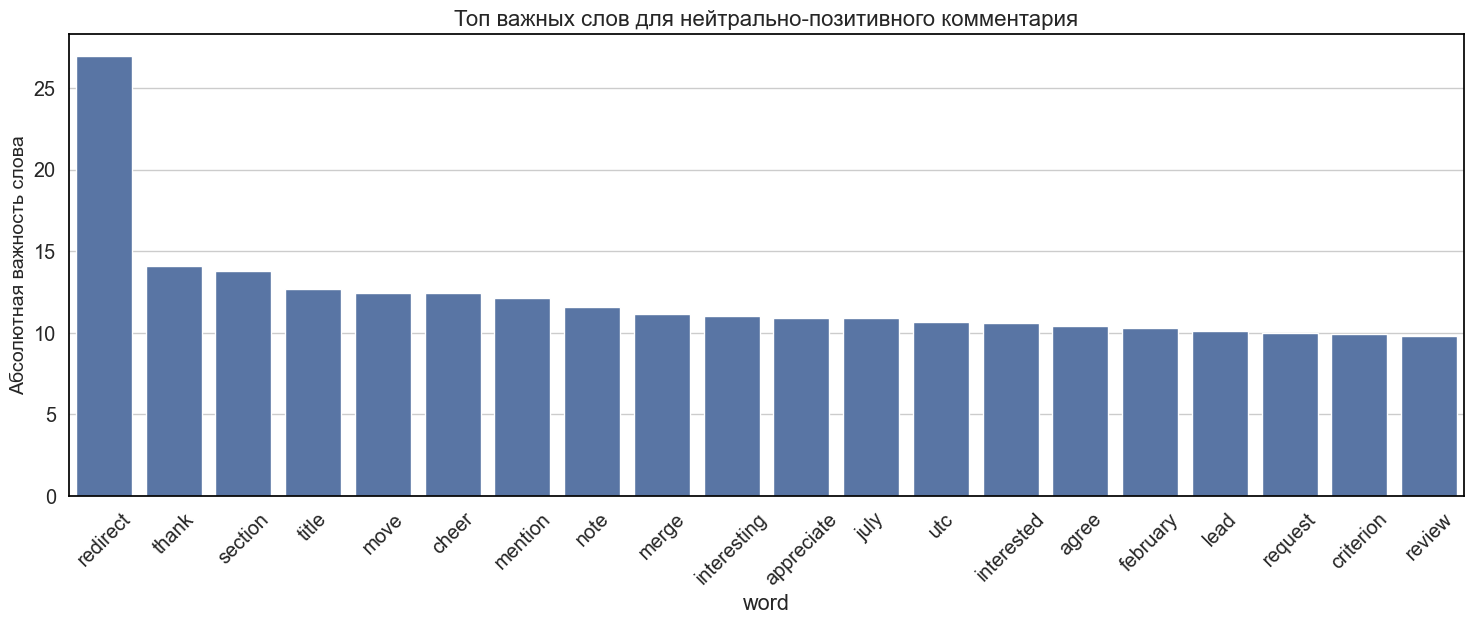

In [44]:
features_importance(bot, 'Топ важных слов для нейтрально-позитивного комментария')

- Видно, что одним из маркеров негативного комментария будет `idiot` и т.д. В целом, основные слова логичны и типичны, заказчик может добавить их в автоматический фильтр, например
- Для позитивно-нейтральных комменатриев сильно выделяется `redirect`, возможно часть ссылки или кусок автоматческого ответа. Так же из интересного это `utc` - остаток от указания времени и некоторые месяцы года

#### Сравнение с константной моделью

Посмотрим на метрики константной модели

Recall - 0.097
Precision - 0.097
Accurcay - 0.817
F1 score - 0.097


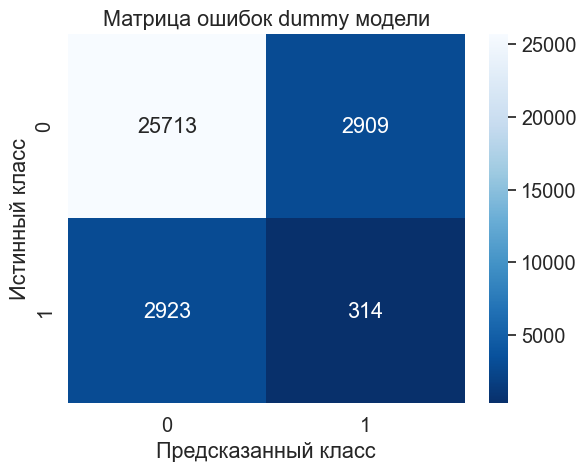

In [45]:
dummy_class = DummyClassifier(strategy='stratified', random_state=RANDOM_STATE)
dummy_class.fit(X_train, y_train)
y_dummy_predict = dummy_class.predict(X_test)
y_dummy_proba = dummy_class.predict_proba(X_test)[:,1]
model_metrics(y_test, y_dummy_predict, 'dummy модели')

Наша модель явно лучше по доле верных ответов - 0.957 против 0.817

### Вывод

- Обучили три модели с подбором гиперпараметров и протестировали предобученную модель BERT
- Все модели на кросс-валидации смогли показать метрику `F1 > 0.75`
    - BERT - 0.926
    - LogisticRegression - 0.777
    - CatBoost - 0.769
    - LGBM - 0.768
- Быстрее всего обучается логистическая регрессия, медленнее всего - BERT
- Встает сложный выбор, BERT или LogisticRegression, который упирается в мощности заказчика
- Выберем логистическую регрессию, так как данная модель выполняет требования заказчика по метрике и значительно превосходит по скорости остальные модели
    - **LogisticRegression** с F1-метрикой - **0.777**
    - Гиперпараметры
        - `С` - 100
        - `max_iter` - 7000
        - `fit_intercept` - True
        - `solver` - `lbfgs`
    - Самая быстрая модель
- При наличии у заказчика достаточных мощностей имеет смысл рассмотреть BERT
    - Модель была откалибрована и был выбран порог 0.35 для повышения охвата модели, так как для нас важнее охватить как можно больше негативных комментариев
    - Метрики модели на тестовой выборке
        - Recall - 0.774
        - Precision - 0.794
        - **F1 score - 0.784**

## Общий вывод

В данном проекте на основе собранных комментариев была создана модель определения тона комментария

**Исходные данные**
- Всего 159292 записи
- Соотношение классов в целевом признаке, есть смещение в пользу отрицательно класса
    - `0` - 89.8 %
    - `1` - 10.2 %
    

**Подготовка и анализ данных**
- Токенизировали и убрали спецсимволы
- Лемматизировали с помощью `Spacy`
- Убрали стоп-слова из словаря `Spacy`, в который добавили остатки вроде `ll`, `nt` и т.д.
- Создали `tf-idf` векторизацию
- Отдельно оставили обработанные, но не векторизованные данные для `CatBoost`, где будем использовать `text_processing`
- Дополнительно создали подвыборку для BERT из 4000 объектов
- По самым частым словам в группе позитивно-нейтральных и негативных комментариев наблюдается заметная разница
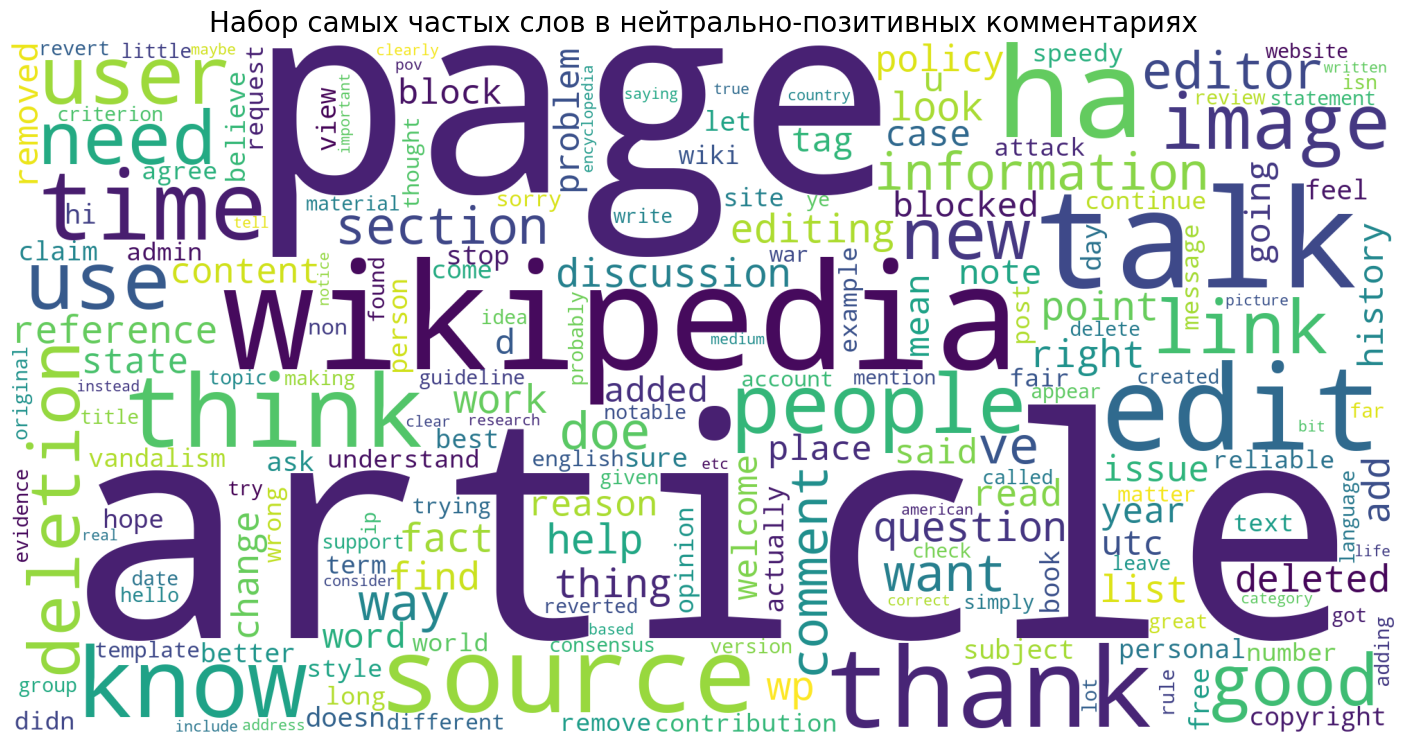

**Обучение моделей**
- С использованием Hyperopt было обучено три вида моделей с перебором гиперпараметров и кросс-валидацией. Для сравнения использовалась метрика F1. Так же протестировали предобученную модель BERT
- Все модели на кросс-валидации смогли показать метрику `F1 > 0.75`
    - BERT - 0.926
    - LogisticRegression - 0.777
    - CatBoost - 0.769
    - LGBM - 0.768
- **Лучшая модель**
    - **LogisticRegression** с F1-метрикой - **0.777** на кросс-валидации
    - Гиперпараметры
        - `С` - 100
        - `max_iter` - 7000
        - `fit_intercept` - True
        - `solver` - `lbfgs`
    - Самая быстрая модель
    - Модель была откалибрована и был выбран порог 0.35 для повышения охвата модели, так как для нас важнее охватить как можно больше негативных комментариев
- **Метрики модели** с порогом 0.35 на тестовой выборке
    - Recall - 0.774
    - Precision - 0.794
    - **F1 score - 0.784**
    - Охват всех возможных негативных комментариев составляет 77.4 %, для чего пришлось немного пожертвовать точностью определения негативных комментариев - 79.4 %, так как для нас важнее выявить как можно больше негативных комментариев

- **Улучшения модели**
    - Попробовать обучить BERT mini модель на видеокартах
    - Рассмотреть варианты ограничения словаря по частоте встречи слова в текстах при создании признаков
    - Попробовать варианты балансировки данных, например выбросить половину нейтрально-позитивных комментариев из обучающей выборки
    

- **Рекомендации заказчику**
    - При наличии достаточных мощностей с GPU использовать BERT модель, так как время обучения и предсказания значительно выше канонических моделей МО
    - При наличии небольших мощностей использовать логистическую регрессию, так как она удовлетворяет критериям метрики и при этом значительно выигрывает в скорости
    - Если мощности на промежуточном положении, то можно создат признаки с помощью эмбединнгов через BERT